In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

## Functions

In [33]:

# ============== DEFAULT CONFIGURATION ==============
_DEFAULT_INTENSITIES = ["Eighth", "Quarter", "Half", "Full"]
_DEFAULT_INTENSITY_COLORS = {'Eighth': '#c7e9c0', 'Quarter': '#74c476', 'Half': '#31a354', 'Full': '#006d2c'}
_DEFAULT_METRICS = [
    "PI_Hg_OSAR", "Log2 Speed ratio_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR",
    "Light Attraction Index_Hg_OSAR", "Bout Number Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR",
    "Max Velocity ratio_Hg_OSAR", "Speed ratio_Hg_OSAR", "Bout Speed ratio_Hg_OSAR"
]
_DEFAULT_METRIC_DISPLAY = {
    "PI_Hg_OSAR": "PI", "Log2 Speed ratio_Hg_OSAR": "Log2 Speed Ratio",
    "Log2 Bout Speed ratio_Hg_OSAR": "Log2 Bout Speed Ratio", "Light Attraction Index_Hg_OSAR": "Light Attraction Index",
    "Bout Number Index_Hg_OSAR": "Bout Number Index", "Bout Duration ratio_Hg_OSAR": "Bout Duration Ratio",
    "Max Velocity ratio_Hg_OSAR": "Max Velocity Ratio", "Speed ratio_Hg_OSAR": "Speed Ratio",
    "Bout Speed ratio_Hg_OSAR": "Bout Speed Ratio"
}

import re  # for MBON number parsing

# ============== DATA LOADING ==============
def load_bootstrap_data(data_path, responders=None, intensities=None, metrics=None):
    intensities = intensities or _DEFAULT_INTENSITIES
    metrics = metrics or _DEFAULT_METRICS
    all_data = {}
    
    for filename in [f for f in os.listdir(data_path) if f.endswith('_bootstrap.csv')]:
        parts = filename.replace('_bootstrap.csv', '').split(' x ')
        if len(parts) != 2: continue
        mbon, responder = parts
        if responders and responder not in responders: continue
        if responder not in all_data:
            all_data[responder] = {i: {m: {} for m in metrics} for i in intensities}
        
        try:
            df = pd.read_csv(os.path.join(data_path, filename))
            for (intensity, metric), group in df.groupby(['Light_Intensity', 'Metric']):
                if intensity in intensities and metric in metrics:
                    all_data[responder][intensity][metric][mbon] = {
                        'bootstrap': group['Bootstrap'].values,
                        'effect': group['Hedges_g'].iloc[0],
                        'ci_low': group['CI_low'].iloc[0],
                        'ci_high': group['CI_high'].iloc[0]
                    }
        except Exception as e:
            print(f"Error reading {filename}: {e}")
    return all_data

def get_effect(data, responder, intensity, metric, mbon):
    try:
        d = data[responder][intensity][metric][mbon]
        return d['effect'], d['ci_low'], d['ci_high']
    except KeyError:
        return None, None, None

def get_bootstrap(data, responder, intensity, metric, mbon):
    try:
        return data[responder][intensity][metric][mbon]['bootstrap']
    except KeyError:
        return np.zeros(5000)

def get_sorted_mbons(data, responder, metric, sort_by='Full'):
    mbons = set()
    for intensity in data[responder]:
        mbons.update(data[responder][intensity][metric].keys())
    return [m for m, _ in sorted([(m, get_effect(data, responder, sort_by, metric, m)[0] or 0) for m in mbons], key=lambda x: x[1])]

def get_mbons_by_number(data, responder, lobelocation):
    mbons = set()
    for intensity in data[responder]:
        for metric in data[responder][intensity]:
            mbons.update(data[responder][intensity][metric].keys())
    
    if lobelocation is None or lobelocation.empty:
        return sorted(list(mbons))
    
    def sort_key(mbon):
        info = lobelocation[lobelocation['MBON'] == mbon]
        if len(info) > 0:
            match = re.search(r'(\d+)', str(info['MBON_number'].values[0]).strip())
            if match: return int(match.group(1))
        return 999
    return sorted(list(mbons), key=sort_key)

def get_available_metrics(metrics=None):
    return metrics or _DEFAULT_METRICS

# ============== HELPER FUNCTIONS ==============
def _create_labels(mbons, lobelocation, sep='\n'):
    if lobelocation is None or lobelocation.empty: return list(mbons)
    labels = []
    for mbon in mbons:
        info = lobelocation[lobelocation['MBON'] == mbon]
        if len(info) > 0:
            parts = [str(info['MBON_number'].values[0]), str(info['Lobe_location'].values[0]), mbon]
            labels.append(sep.join([p for p in parts if p and p != 'nan']) or mbon)
        else:
            labels.append(mbon)
    return labels

def find_number(df, lookup, col):
    vals = []
    for _, row in df.iterrows():
        if lookup in [x.strip() for x in row['MBON names'].split(',')]:
            vals.append(row[col])
    return ', '.join(list(set(vals)))

def _get_text_color_from_center(spirals, row_idx, col_idx, n, cmap, vmin, vmax):
    """Get text color based on center 3x3 region of spiral cell."""
    cy, cx = row_idx * n + n // 2, col_idx * n + n // 2
    center_val = np.mean(spirals[cy-1:cy+2, cx-1:cx+2])
    norm_val = np.clip((center_val - vmin) / (vmax - vmin), 0, 1) if vmax != vmin else 0.5
    cmap_obj = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    rgba = cmap_obj(norm_val)
    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return 'white' if luminance < 0.5 else 'black'

# ============== VORTEXMAP ==============
def _sample_bootstrap(bootstrap, m, n, chop_tail=2.5):
    bs = sorted(bootstrap)
    chop = int(np.ceil(len(bs) * chop_tail / 100))
    bs = bs[chop:len(bs)-chop]
    ranks = np.linspace(0, len(bs), m*n, dtype=int)
    ranks[0] = 1
    if np.sum(np.array(bs) > 0) < len(bs)/2: bs = bs[::-1]
    return [bs[r-1] for r in ranks]

def _spiralize(fill, m, n):
    i, j, k = 0, 0, 0
    arr = np.zeros((m, n))
    while m > 0 and k < len(fill):
        jj, ii = j, i
        for j in range(j, n):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for i in range(ii+1, m):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for j in range(n-2, jj-1, -1):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for i in range(m-2, ii, -1):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        m -= 1; n -= 1; j += 1
    return arr

def create_vortexmap(data, responder, metric, intensities=None, lobelocation=None,
                     cmap='coolwarm', figsize=None, chop_tail=2.5,
                     vmin=None, vmax=None,
                     annot=True, annot_fontsize=9, annot_fmt='.2f',
                     title=None, title_fontsize=14, title_fontweight='bold',
                     xlabel=None, xlabel_fontsize=12,
                     xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                     ylabel=None, ylabel_fontsize=12,
                     yticklabels=None, yticklabels_fontsize=10, yticklabels_rotation=0,
                     yticklabels_sep=' --- ',
                     cbar=True, cbar_label="Hedge's g", cbar_orientation='horizontal',
                     cbar_ticks=[-1, 0, 1],
                     cbar_x=None, cbar_y=None, cbar_width=0.3, cbar_height=0.02,
                     cbar_labelsize=10, cbar_ticksize=8):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    mbons = get_mbons_by_number(data, responder, lobelocation)
    n = 9 if len(mbons) > 30 else (11 if len(mbons) > 15 else 15)
    n_rows, n_cols = len(mbons), len(intensities)
    vmin = vmin if vmin is not None else cbar_ticks[0]
    vmax = vmax if vmax is not None else cbar_ticks[-1]
    
    spirals = np.zeros((n_rows*n, n_cols*n))
    mean_vals = np.zeros((n_rows, n_cols))
    for i, mbon in enumerate(mbons):
        for j, intensity in enumerate(intensities):
            samples = _sample_bootstrap(get_bootstrap(data, responder, intensity, metric, mbon), n, n, chop_tail)
            spirals[i*n:(i+1)*n, j*n:(j+1)*n] = _spiralize(samples, n, n)
            mean_vals[i, j] = np.mean(samples)
    
    fig, ax = plt.subplots(figsize=figsize or (n_cols*2.5, n_rows*0.6))
    sns.heatmap(spirals, cmap=cmap, vmin=vmin, vmax=vmax, center=0, cbar=False, ax=ax)
    
    ax.set_xticks(np.linspace(n/2, n_cols*n-n/2, n_cols))
    ax.set_xticklabels(xticklabels or intensities, rotation=xticklabels_rotation, ha='center', fontsize=xticklabels_fontsize)
    if xlabel: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    
    ax.set_yticks(np.linspace(n/2, n_rows*n-n/2, n_rows))
    ax.set_yticklabels(yticklabels or _create_labels(mbons, lobelocation, sep=yticklabels_sep), 
                       rotation=yticklabels_rotation, fontsize=yticklabels_fontsize)
    if ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    if title: ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
    
    if annot:
        for i in range(n_rows):
            for j in range(n_cols):
                ax.text(j*n+n/2, i*n+n/2, f'{mean_vals[i,j]:{annot_fmt}}', ha='center', va='center',
                       fontsize=annot_fontsize, color=_get_text_color_from_center(spirals, i, j, n, cmap, vmin, vmax))
    
    if cbar:
        cax = fig.add_axes([cbar_x or 0.25, cbar_y or 0.02, cbar_width, cbar_height])
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), 
                         cax=cax, orientation=cbar_orientation)
        cb.set_ticks(cbar_ticks)
        cb.set_label(cbar_label, fontsize=cbar_labelsize)
        cb.ax.tick_params(labelsize=cbar_ticksize)
    
    plt.tight_layout()
    return fig, ax, mbons, mean_vals

def create_multi_vortexmap(data, responder, metrics, intensities=None, lobelocation=None,
                           cmap='coolwarm', figsize=None, chop_tail=2.5,
                           vmin=None, vmax=None,
                           annot=True, annot_fontsize=8, annot_fmt='.2f',
                           title=None, title_fontsize=16, title_fontweight='bold', title_y=0.99,
                           subplot_titles=None, subplot_title_fontsize=14, subplot_title_fontweight='bold',
                           xlabel=None, xlabel_fontsize=12,
                           xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                           ylabel=None, ylabel_fontsize=12,
                           yticklabels=None, yticklabels_fontsize=10, yticklabels_rotation=0,
                           yticklabels_sep=' --- ',
                           cbar=True, cbar_label="Hedge's g", cbar_orientation='horizontal',
                           cbar_ticks=[-1, 0, 1],
                           cbar_x=None, cbar_y=None, cbar_width=0.3, cbar_height=0.015,
                           cbar_labelsize=10, cbar_ticksize=8,
                           layout_rect=None, metric_display=None):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_mbons_by_number(data, responder, lobelocation)
    n = 9 if len(mbons) > 30 else (11 if len(mbons) > 15 else 15)
    n_rows, n_cols, n_metrics = len(mbons), len(intensities), len(metrics)
    vmin = vmin if vmin is not None else cbar_ticks[0]
    vmax = vmax if vmax is not None else cbar_ticks[-1]
    
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize or (5*n_metrics, n_rows*0.6))
    if n_metrics == 1: axes = [axes]
    subplot_titles = subplot_titles or [metric_display.get(m, m) for m in metrics]
    ytick_labels = yticklabels or _create_labels(mbons, lobelocation, sep=yticklabels_sep)
    all_mean_vals = []
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        spirals = np.zeros((n_rows*n, n_cols*n))
        mean_vals = np.zeros((n_rows, n_cols))
        
        for i, mbon in enumerate(mbons):
            for j, intensity in enumerate(intensities):
                samples = _sample_bootstrap(get_bootstrap(data, responder, intensity, metric, mbon), n, n, chop_tail)
                spirals[i*n:(i+1)*n, j*n:(j+1)*n] = _spiralize(samples, n, n)
                mean_vals[i, j] = np.mean(samples)
        all_mean_vals.append(mean_vals)
        
        sns.heatmap(spirals, cmap=cmap, vmin=vmin, vmax=vmax, center=0, cbar=False, ax=ax)
        ax.set_title(subplot_titles[idx], fontsize=subplot_title_fontsize, fontweight=subplot_title_fontweight)
        ax.set_xticks(np.linspace(n/2, n_cols*n-n/2, n_cols))
        ax.set_xticklabels(xticklabels or intensities, rotation=xticklabels_rotation, ha='center', fontsize=xticklabels_fontsize)
        if xlabel and idx == n_metrics // 2: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
        ax.set_yticks(np.linspace(n/2, n_rows*n-n/2, n_rows))
        ax.set_yticklabels(ytick_labels, rotation=yticklabels_rotation, fontsize=yticklabels_fontsize)
        if idx == 0 and ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
        if idx != 0: ax.tick_params(labelleft=False)
        
        if annot:
            for i in range(n_rows):
                for j in range(n_cols):
                    ax.text(j*n+n/2, i*n+n/2, f'{mean_vals[i,j]:{annot_fmt}}', ha='center', va='center',
                           fontsize=annot_fontsize, color=_get_text_color_from_center(spirals, i, j, n, cmap, vmin, vmax))
    
    if title: fig.suptitle(title, fontsize=title_fontsize, fontweight=title_fontweight, y=title_y)
    if cbar:
        cax = fig.add_axes([cbar_x or 0.35, cbar_y or 0.02, cbar_width, cbar_height])
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)),
                         cax=cax, orientation=cbar_orientation)
        cb.set_ticks(cbar_ticks)
        cb.set_label(cbar_label, fontsize=cbar_labelsize)
        cb.ax.tick_params(labelsize=cbar_ticksize)
    
    plt.tight_layout(rect=layout_rect or [0, 0.05, 1, 0.96])
    return fig, axes, mbons, all_mean_vals

# ============== HEATMAP ==============
def create_heatmap(data, responder, metric, intensities=None, lobelocation=None, 
                   cmap='coolwarm', vmin=-1.5, vmax=1.5, figsize=None,
                   annot=True, annot_fontsize=10, annot_fmt='.2f',
                   title=None, title_fontsize=14, title_fontweight='bold',
                   xlabel=None, xlabel_fontsize=12,
                   xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                   ylabel=None, ylabel_fontsize=12,
                   yticklabels_fontsize=10, yticklabels_rotation=0,
                   yticklabels_sep=' --- ',
                   cbar=True, cbar_label="Hedge's g"):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    mbons = get_sorted_mbons(data, responder, metric)
    matrix = [[get_effect(data, responder, i, metric, m)[0] or np.nan for i in intensities] for m in mbons]
    df = pd.DataFrame(matrix, index=_create_labels(mbons, lobelocation, sep=yticklabels_sep),
                      columns=xticklabels or intensities)
    
    fig, ax = plt.subplots(figsize=figsize or (8, len(mbons)*0.4))
    sns.heatmap(df, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
                annot=annot, fmt=annot_fmt, annot_kws={'fontsize': annot_fontsize},
                cbar=cbar, cbar_kws={'label': cbar_label} if cbar else None, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=xticklabels_fontsize, rotation=xticklabels_rotation)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=yticklabels_fontsize, rotation=yticklabels_rotation)
    if xlabel: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    if ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    if title: ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
    plt.tight_layout()
    return fig, ax, df

def create_multi_heatmap(data, responder, metrics, intensities=None, lobelocation=None,
                         cmap='coolwarm', figsize=None, vmin=None, vmax=None,
                         annot=True, annot_fontsize=9, annot_fmt='.2f',
                         title=None, title_fontsize=16, title_fontweight='bold', title_y=0.99,
                         subplot_titles=None, subplot_title_fontsize=14, subplot_title_fontweight='bold',
                         xlabel=None, xlabel_fontsize=12,
                         xticklabels=None, xticklabels_fontsize=10, xticklabels_rotation=0,
                         ylabel=None, ylabel_fontsize=12,
                         yticklabels_fontsize=10, yticklabels_rotation=0,
                         yticklabels_sep=' --- ',
                         cbar=True, cbar_label="Hedge's g", cbar_orientation='horizontal',
                         cbar_ticks=[-1, 0, 1],
                         cbar_x=None, cbar_y=None, cbar_width=0.3, cbar_height=0.015,
                         cbar_labelsize=10, cbar_ticksize=8,
                         layout_rect=None, metric_display=None):
    
    intensities = intensities or _DEFAULT_INTENSITIES
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_mbons_by_number(data, responder, lobelocation)
    labels = _create_labels(mbons, lobelocation, sep=yticklabels_sep)
    n_metrics = len(metrics)
    vmin = vmin if vmin is not None else cbar_ticks[0]
    vmax = vmax if vmax is not None else cbar_ticks[-1]
    
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize or (4*n_metrics, len(mbons)*0.4))
    if n_metrics == 1: axes = [axes]
    subplot_titles = subplot_titles or [metric_display.get(m, m) for m in metrics]
    all_dfs = []
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        matrix = [[get_effect(data, responder, i, metric, m)[0] or np.nan for i in intensities] for m in mbons]
        df = pd.DataFrame(matrix, index=labels, columns=xticklabels or intensities)
        all_dfs.append(df)
        
        sns.heatmap(df, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
                    annot=annot, fmt=annot_fmt, annot_kws={'fontsize': annot_fontsize}, cbar=False, ax=ax)
        ax.set_title(subplot_titles[idx], fontsize=subplot_title_fontsize, fontweight=subplot_title_fontweight)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=xticklabels_fontsize, rotation=xticklabels_rotation)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=yticklabels_fontsize, rotation=yticklabels_rotation)
        if idx == 0 and ylabel: ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
        if idx != 0: ax.tick_params(labelleft=False)
        if xlabel and idx == n_metrics // 2: ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    
    if title: fig.suptitle(title, fontsize=title_fontsize, fontweight=title_fontweight, y=title_y)
    if cbar:
        cax = fig.add_axes([cbar_x or 0.35, cbar_y or 0.02, cbar_width, cbar_height])
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)),
                         cax=cax, orientation=cbar_orientation)
        cb.set_ticks(cbar_ticks)
        cb.set_label(cbar_label, fontsize=cbar_labelsize)
        cb.ax.tick_params(labelsize=cbar_ticksize)
    plt.tight_layout(rect=layout_rect or [0, 0.05, 1, 0.96])
    return fig, axes, mbons, all_dfs

# ============== FOREST PLOT ==============
def create_forest_plot(data, responder, metric, intensities=None, lobelocation=None,
                       colors=None, xlim=(-2,2), figsize=None, show_violin=True,
                       title=None, title_fontsize=14, title_fontweight='bold',
                       xlabel=None, xlabel_fontsize=12,
                       yticklabels_fontsize=10, yticklabels_sep='\n',
                       legend_loc='lower right', metric_display=None):
    from scipy import stats
    from matplotlib.patches import Patch
    
    intensities = intensities or _DEFAULT_INTENSITIES
    colors = colors or _DEFAULT_INTENSITY_COLORS
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_sorted_mbons(data, responder, metric)
    n_int, n_mbon = len(intensities), len(mbons)
    
    fig, ax = plt.subplots(figsize=figsize or (12, n_mbon*n_int*0.25+2))
    for i, mbon in enumerate(mbons):
        for j, intensity in enumerate(intensities):
            effect, ci_low, ci_high = get_effect(data, responder, intensity, metric, mbon)
            if effect is None: continue
            row = (n_mbon-1-i)*n_int + (n_int-1-j)
            color = colors.get(intensity, '#888')
            
            if show_violin:
                bootstrap = get_bootstrap(data, responder, intensity, metric, mbon)
                bootstrap = bootstrap[~np.isnan(bootstrap)]
                if len(bootstrap) > 1:
                    kde = stats.gaussian_kde(bootstrap)
                    x = np.linspace(min(bootstrap)-0.1, max(bootstrap)+0.1, 200)
                    ax.fill_between(x, row, row + kde(x)/kde(x).max()*0.35, color=color, alpha=0.6)
            ax.hlines(row, ci_low, ci_high, color=color, linewidth=2.5)
            ax.scatter(effect, row, color=color, s=50, zorder=5, edgecolor='white')
    
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_yticks([(n_mbon-1-i)*n_int + (n_int-1)/2 for i in range(n_mbon)])
    ax.set_yticklabels(_create_labels(mbons[::-1], lobelocation, sep=yticklabels_sep), fontsize=yticklabels_fontsize)
    ax.set_xlabel(xlabel or f'Effect Size ({metric_display.get(metric, metric)})', fontsize=xlabel_fontsize)
    ax.set_xlim(xlim)
    ax.grid(axis='x', alpha=0.3)
    if title: ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
    ax.legend(handles=[Patch(color=colors.get(i,'#888'), label=i) for i in intensities], loc=legend_loc)
    plt.tight_layout()
    return fig, ax

def create_multi_forest_plot(data, responder, metrics, intensities=None, lobelocation=None,
                             colors=None, xlim=(-2,2), figsize=None, show_violin=True,
                             title=None, title_fontsize=16, title_fontweight='bold', title_y=0.99,
                             subplot_titles=None, subplot_title_fontsize=14, subplot_title_fontweight='bold',
                             xlabel=None, xlabel_fontsize=12,
                             yticklabels_fontsize=10, yticklabels_sep='\n',
                             legend_loc='lower right', show_legend='last',
                             layout_rect=None, metric_display=None):
    from scipy import stats
    from matplotlib.patches import Patch
    
    intensities = intensities or _DEFAULT_INTENSITIES
    colors = colors or _DEFAULT_INTENSITY_COLORS
    metric_display = metric_display or _DEFAULT_METRIC_DISPLAY
    mbons = get_mbons_by_number(data, responder, lobelocation)
    n_int, n_mbon, n_metrics = len(intensities), len(mbons), len(metrics)
    ytick_labels = _create_labels(mbons[::-1], lobelocation, sep=yticklabels_sep)
    
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize or (6*n_metrics, n_mbon*n_int*0.25+2))
    if n_metrics == 1: axes = [axes]
    subplot_titles = subplot_titles or [metric_display.get(m, m) for m in metrics]
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        for i, mbon in enumerate(mbons):
            for j, intensity in enumerate(intensities):
                effect, ci_low, ci_high = get_effect(data, responder, intensity, metric, mbon)
                if effect is None: continue
                row = (n_mbon-1-i)*n_int + (n_int-1-j)
                color = colors.get(intensity, '#888')
                
                if show_violin:
                    bootstrap = get_bootstrap(data, responder, intensity, metric, mbon)
                    bootstrap = bootstrap[~np.isnan(bootstrap)]
                    if len(bootstrap) > 1:
                        kde = stats.gaussian_kde(bootstrap)
                        x = np.linspace(min(bootstrap)-0.1, max(bootstrap)+0.1, 200)
                        ax.fill_between(x, row, row + kde(x)/kde(x).max()*0.35, color=color, alpha=0.6)
                ax.hlines(row, ci_low, ci_high, color=color, linewidth=2.5)
                ax.scatter(effect, row, color=color, s=50, zorder=5, edgecolor='white')
        
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlim(xlim)
        ax.grid(axis='x', alpha=0.3)
        ax.set_title(subplot_titles[idx], fontsize=subplot_title_fontsize, fontweight=subplot_title_fontweight)
        ax.set_yticks([(n_mbon-1-i)*n_int + (n_int-1)/2 for i in range(n_mbon)])
        ax.set_yticklabels(ytick_labels, fontsize=yticklabels_fontsize)
        if idx != 0: ax.tick_params(labelleft=False)
        if idx == n_metrics // 2: ax.set_xlabel(xlabel or "Hedge's g", fontsize=xlabel_fontsize)
        if show_legend == 'all' or (show_legend == 'last' and idx == n_metrics - 1):
            ax.legend(handles=[Patch(color=colors.get(i,'#888'), label=i) for i in intensities], loc=legend_loc)
    
    if title: fig.suptitle(title, fontsize=title_fontsize, fontweight=title_fontweight, y=title_y)
    plt.tight_layout(rect=layout_rect or [0, 0, 1, 0.96])
    return fig, axes, mbons

## Code

In [34]:
# ============== CONFIGURATION ==============
# These are user-configurable aliases to the module defaults
# You can modify these or pass custom values directly to functions

DEFAULT_INTENSITY_COLORS = _DEFAULT_INTENSITY_COLORS.copy()
INTENSITIES = _DEFAULT_INTENSITIES.copy()
METRICS = _DEFAULT_METRICS.copy()
METRIC_DISPLAY = _DEFAULT_METRIC_DISPLAY.copy()

# You can customize here, for example:
# INTENSITIES = ["Quarter", "Full"]  # Only use some intensities
# METRIC_DISPLAY["PI_Hg_OSAR"] = "Custom PI Name"  # Custom display name

In [ ]:
# ============== LOAD DATA ==============
data_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\osar_compiled\Bootstrapped stats"
responders = ["ACR", "Chrimson2"]

print("Loading pre-computed bootstrap data...")
osar_data = load_bootstrap_data(data_path, responders=responders)
[[osar_data[r][i][m].pop('R76B09', None) for r in osar_data for i in osar_data[r] for m in osar_data[r][i]]]


Loading pre-computed bootstrap data...


In [53]:

responder = "ACR"

In [54]:
# ============== LOAD MBON INFO ==============
mbon_csv_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"
lobelocation = pd.DataFrame()

try:
    csvfile = pd.read_csv(mbon_csv_path).astype('string')
    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)
    
    mbons = get_sorted_mbons(osar_data, responder, METRICS[0])
    for m in mbons:
        row = {'MBON': m, 'Lobe_location': find_number(csvfile, m, "Lobe"),
               'MBON_number': find_number(csvfile, m, "MBON number").strip()}
        lobelocation = pd.concat([lobelocation, pd.DataFrame([row])])
    lobelocation = lobelocation.reset_index(drop=True)
    print(f"Loaded MBON info for {len(lobelocation)} MBONs")
except Exception as e:
    print(f"Could not load MBON info: {e}")

Loaded MBON info for 27 MBONs


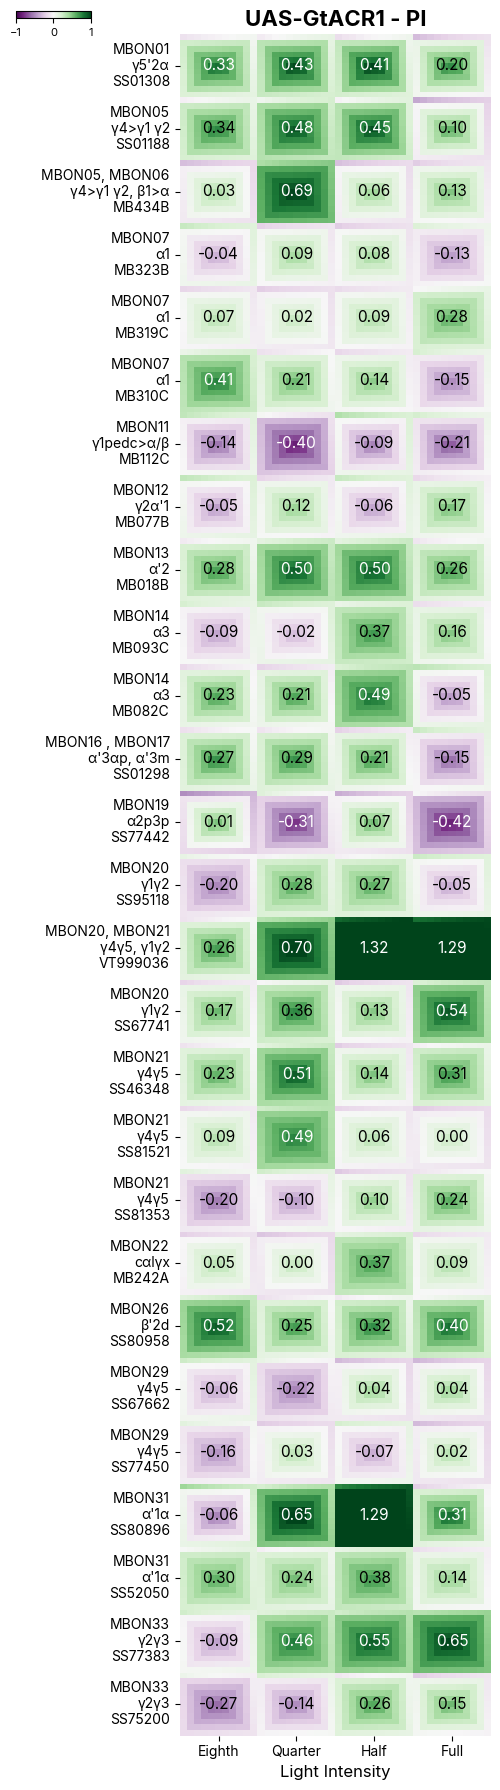

In [55]:
# ============== VORTEXMAP ==============
metric = METRICS[0]  # PI_Hg_OSAR

if responder == "ACR":
    responderrename = "UAS-GtACR1"
    colormap = "PRGn"
if responder == "Chrimson2":
    responderrename = "UAS-CsChrimson"
    colormap = "coolwarm"
    
fig, ax, mbons, vals = create_vortexmap(
    osar_data, responder, metric,
    lobelocation=lobelocation,           # Y-tick labels: MBON number --- Lobe --- driver
    figsize=(5, 18),
    cmap=colormap,
      

    title=f'{responderrename} - {METRIC_DISPLAY[metric]}',
    title_fontsize=16, title_fontweight='bold',

    xlabel='Light Intensity', xlabel_fontsize=12,
    xticklabels_fontsize=10, xticklabels_rotation=0,

    ylabel=' ',
    yticklabels_fontsize=10, yticklabels_rotation=0,
    yticklabels_sep='\n',
 
    annot=True, annot_fontsize=11, annot_fmt='.2f',  # format: .2f, .3f, .1e, etc.
    # Colorbar - precise x,y positioning (0-1 figure coords)
    cbar=True, cbar_label=" ", cbar_orientation='horizontal',
    cbar_x=0.02, cbar_y=0.987, cbar_width=0.15, cbar_height=0.004, cbar_ticks=[-1, 0, 1],
    cbar_labelsize=10, cbar_ticksize=8
)
mpl.rcParams['svg.fonttype'] = 'none' 
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\Singlemetricvortexmapcomp_" + date + "_" + responder + ".svg")
plt.show()

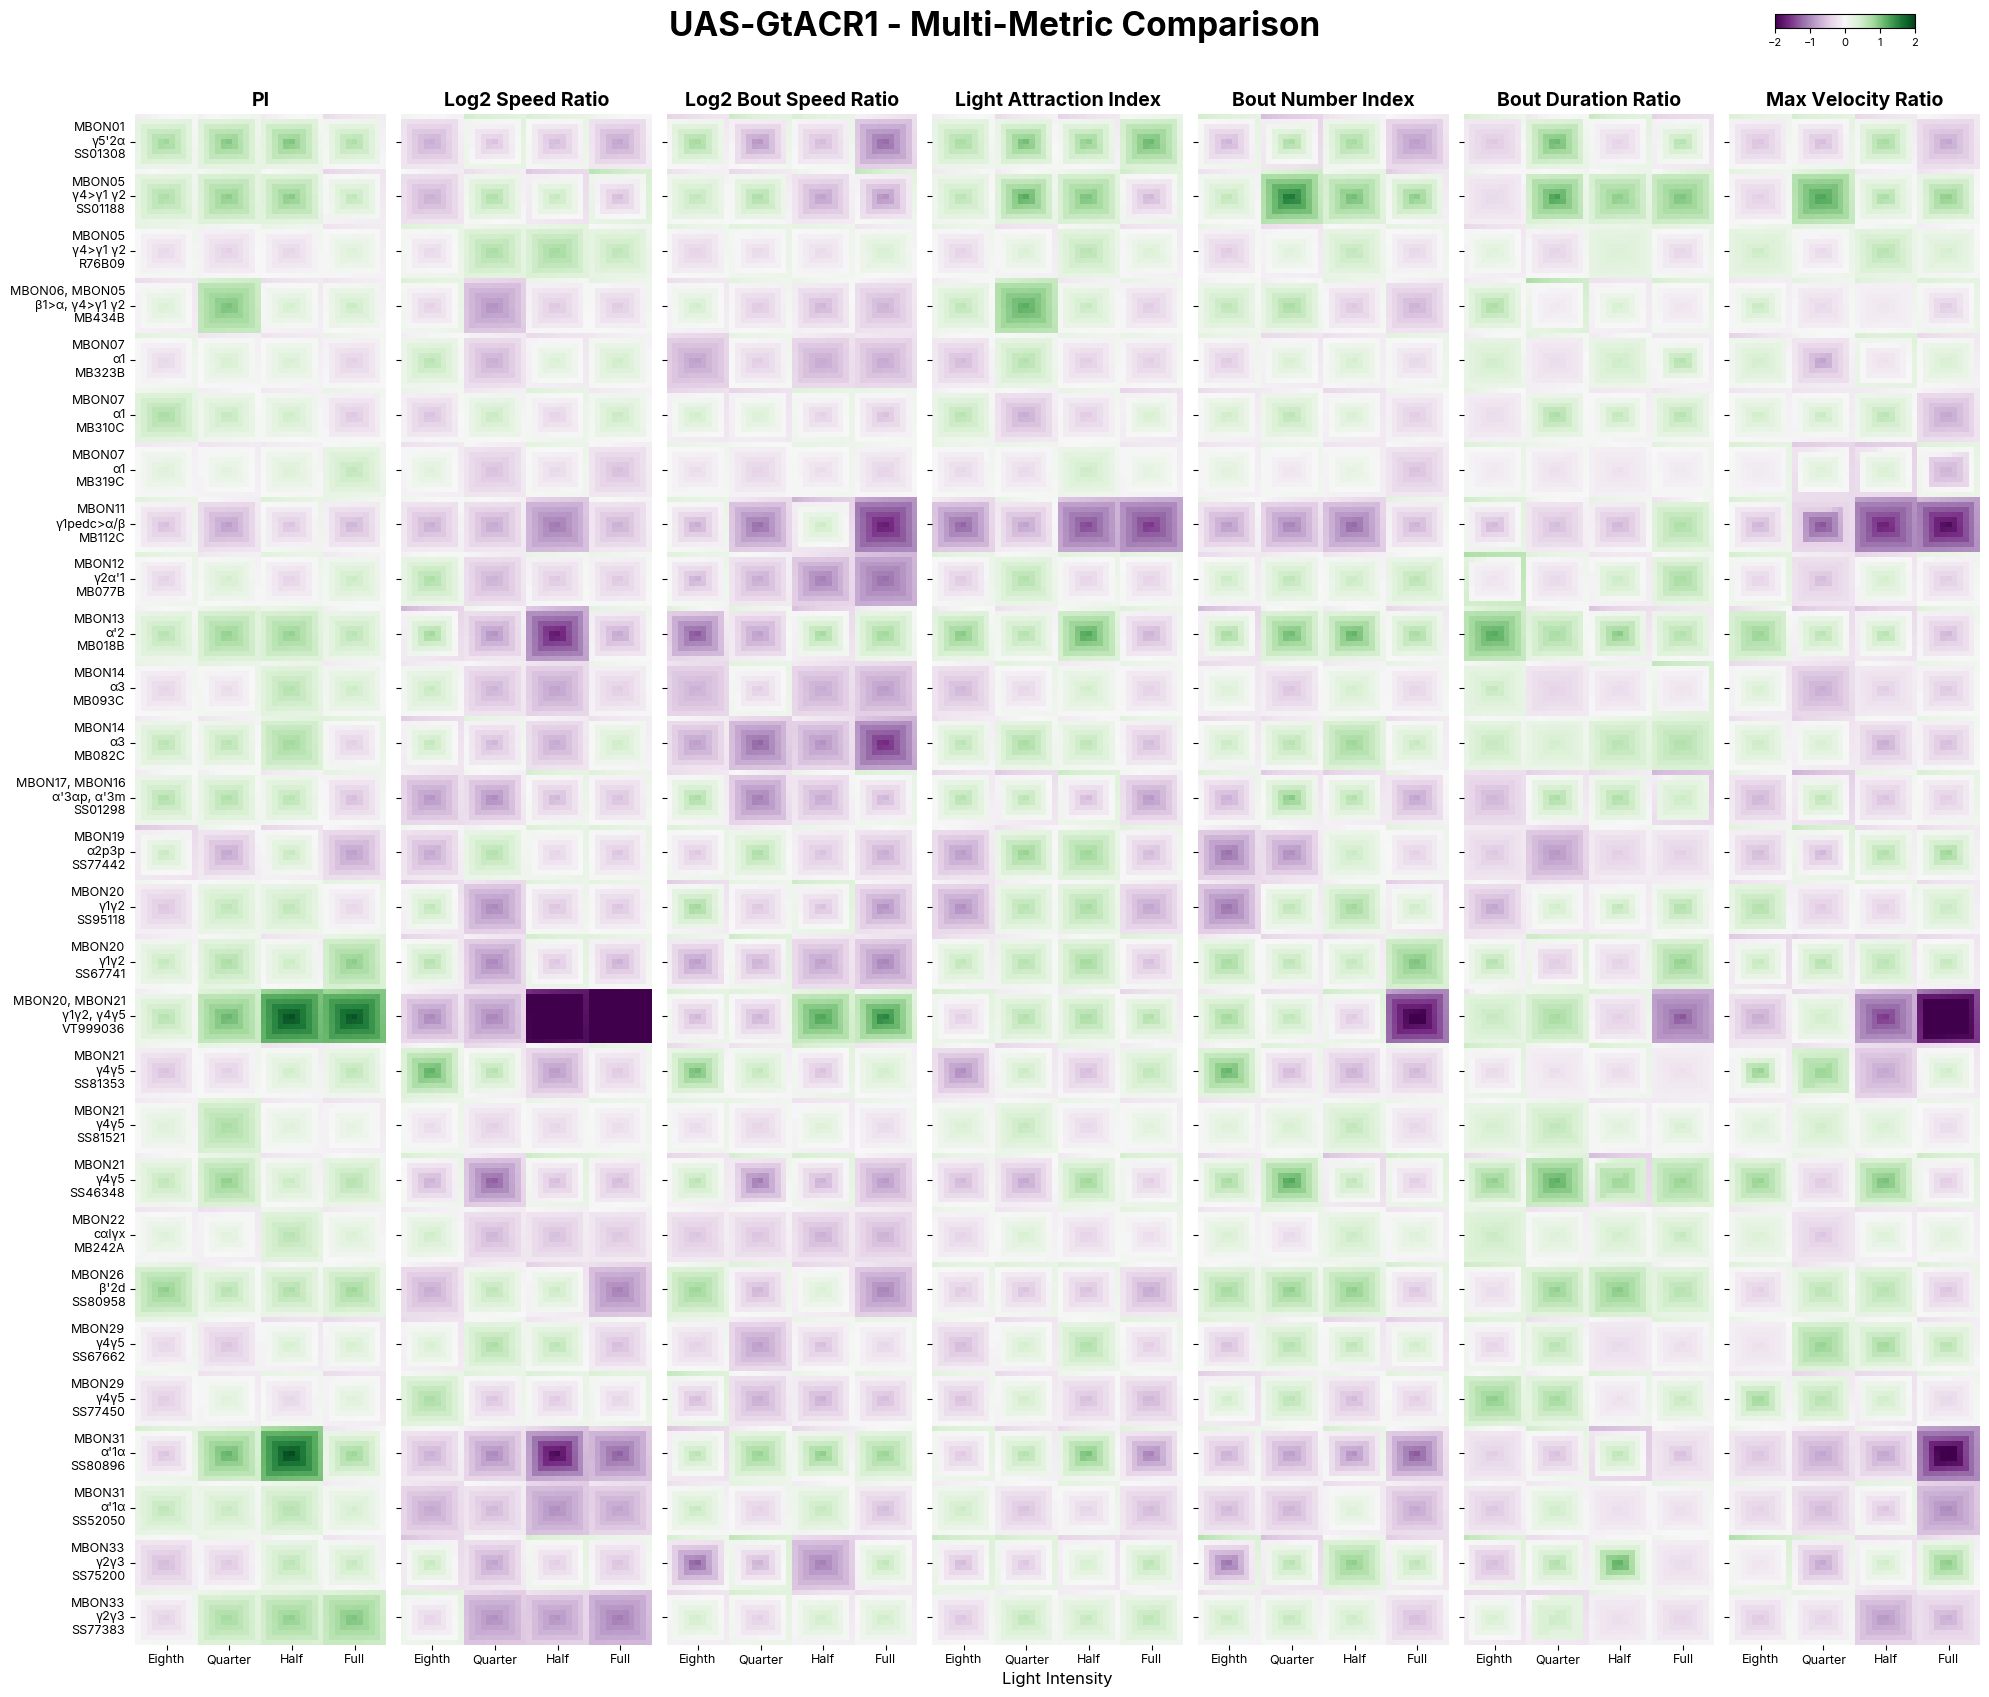

In [8]:
# ============== MULTI-METRIC VORTEXMAP ==============
metrics_to_plot = METRICS[:-2]  # First 3 metrics

responder = "ACR"

if responder == "ACR":
    responderrename = "UAS-GtACR1"
    colormap = "PRGn"
if responder == "Chrimson2":
    responderrename = "UAS-CsChrimson"
    colormap = "coolwarm"

fig, axes, mbons, vals = create_multi_vortexmap(
    osar_data, responder, metrics_to_plot,
    lobelocation=lobelocation,
    figsize=(20, 18),
    cmap= colormap,
    vmin = -2.0,
    vmax = 2.0,
    layout_rect=[0, 0.05, 1, 0.98],
    
    # Overall title
    title=responderrename + ' - Multi-Metric Comparison',
    title_fontsize=24, title_fontweight='bold',
    
    # Subplot titles (one per metric)
    subplot_titles=None,  # Uses METRIC_DISPLAY by default
    subplot_title_fontsize=14, subplot_title_fontweight='bold',
    
    # X-axis
    xlabel='Light Intensity', xlabel_fontsize=12,
    xticklabels_fontsize=9, xticklabels_rotation=0,
    
    # Y-axis (only on leftmost plot)
    yticklabels_fontsize=9, yticklabels_rotation=0,
    yticklabels_sep='\n',
    
    # Annotations
    annot=False, 
    
    # Colorbar
    cbar=True, cbar_label=" ", cbar_orientation='horizontal',
    cbar_x=0.89, cbar_y=0.98, cbar_width=0.07, cbar_height=0.008, cbar_ticks=[-2, -1, 0, 1, 2],
    cbar_labelsize=15, cbar_ticksize=8
)

plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\Multimetricvortexmapcomp_" + date + "_" + responder + ".svg")

plt.show()

## forest plot

In [ ]:
# ============== FOREST PLOT (single metric) ==============
metric = METRICS[0]  # PI_Hg_OSAR
fig, ax = create_forest_plot(
    osar_data, "ACR", metric, 
    lobelocation=lobelocation, 
    show_violin=True,
    title=f'ACR - {METRIC_DISPLAY[metric]} Forest Plot',
    title_fontsize=14, title_fontweight='bold',
    yticklabels_fontsize=9,
    yticklabels_sep=' --- '
)
plt.show()

In [ ]:
# ============== MULTI-METRIC FOREST PLOT ==============
metrics_to_plot = METRICS[:3]  # First 3 metrics

fig, axes, mbons = create_multi_forest_plot(
    osar_data, "ACR", metrics_to_plot,
    lobelocation=lobelocation,
    figsize=(18, 30),
    show_violin=True,
    xlim=(-2, 2),
    
    # Overall title
    title='ACR - Multi-Metric Forest Plot',
    title_fontsize=16, title_fontweight='bold',
    
    # Subplot titles
    subplot_titles=None,  # Uses METRIC_DISPLAY by default
    subplot_title_fontsize=14, subplot_title_fontweight='bold',
    
    # X-axis
    xlabel="Hedge's g", xlabel_fontsize=12,
    
    # Y-axis (only on leftmost plot)
    yticklabels_fontsize=9,
    yticklabels_sep=' --- ',
    
    # Legend
    legend_loc='lower right',
    show_legend='last'  # 'last', 'all', or 'none'
)
plt.show()

In [ ]:
# ============== HEATMAP (single metric) ==============
metric = METRICS[0]  # PI_Hg_OSAR
fig, ax, df = create_heatmap(
    osar_data, "ACR", metric, 
    lobelocation=lobelocation, 
    figsize=(8, 12),
    cmap='coolwarm',
    vmin=-1, vmax=1,
    title=f'ACR - {METRIC_DISPLAY[metric]} Heatmap',
    title_fontsize=14, title_fontweight='bold',
    xlabel='Light Intensity', xlabel_fontsize=12,
    yticklabels_fontsize=9,
    yticklabels_sep=' --- ',
    annot=True, annot_fontsize=10, annot_fmt='.2f'
)
plt.show()

In [ ]:
# ============== MULTI-METRIC HEATMAP ==============
metrics_to_plot = METRICS[:3]  # First 3 metrics

fig, axes, mbons, dfs = create_multi_heatmap(
    osar_data, "ACR", metrics_to_plot,
    lobelocation=lobelocation,
    figsize=(12, 12),
    cmap='coolwarm',
    cbar_ticks=[-1, 0, 1],
    
    # Overall title
    title='ACR - Multi-Metric Heatmap',
    title_fontsize=16, title_fontweight='bold',
    
    # Subplot titles
    subplot_titles=None,  # Uses METRIC_DISPLAY by default
    subplot_title_fontsize=14, subplot_title_fontweight='bold',
    
    # X-axis
    xlabel='Light Intensity', xlabel_fontsize=12,
    xticklabels_fontsize=10, xticklabels_rotation=0,
    
    # Y-axis (only on leftmost plot)
    yticklabels_fontsize=9, yticklabels_rotation=0,
    yticklabels_sep=' --- ',
    
    # Annotations
    annot=True, annot_fontsize=9, annot_fmt='.2f',
    
    # Colorbar
    cbar=True, cbar_label="Hedge's g", cbar_orientation='horizontal',
    cbar_x=0.35, cbar_y=0.02, cbar_width=0.3, cbar_height=0.015,
    cbar_labelsize=10, cbar_ticksize=8
)
plt.show()